
# Probabilistic Principal Component Analysis (PPCA) on Digits Dataset

This code implements PPCA by two methods:
1. ML solution using spectral decomposition.
2. EM algorithm for PPCA.

The data is loaded from the digits dataset in sklearn, and we perform dimensionality reduction and projection on the training set.


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh, inv
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
# Set display configuration
%config InlineBackend.figure_format = "retina"
np.set_printoptions(precision=4, suppress=True)


## Data Loading
Load the digits dataset.


In [24]:
digits = load_digits()
X = digits.data      # Each sample is 64-dimensional (8x8 image)
y = digits.target
print("X shape:", X.shape)
print("Unique labels:", np.unique(y))

Xtrain = X
ytrain = y
N, D = Xtrain.shape
print("Train set shape:", Xtrain.shape)

X shape: (1797, 64)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Train set shape: (1797, 64)


In [25]:
# @title
# This function is used to visualize the digits.  No need to fully understand it
# I just want to show you the data
def visualize_digits(X, y, n_samples=10, random_state=42):
    """
    Visualize random digit samples from the dataset

    Parameters:
    -----------
    X : array-like of shape (n_samples, 64)
        The digit image data (flattened 8x8 images)
    y : array-like of shape (n_samples,)
        The labels
    n_samples : int
        Number of samples to visualize
    random_state : int
        Random seed for reproducibility
    """
    # Set random seed
    np.random.seed(random_state)

    # Randomly select indices
    indices = np.random.choice(len(X), n_samples, replace=False)

    # Create subplot grid
    n_cols = 5
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))

    # Flatten axes for easier iteration
    axes = axes.ravel()

    # Plot each digit
    for idx, ax in enumerate(axes):
        if idx < n_samples:
            # Reshape the flattened image back to 8x8
            digit_image = X[indices[idx]].reshape(8, 8)

            # Plot the image
            ax.imshow(digit_image, cmap='gray')
            ax.set_title(f'Label: {y[indices[idx]]}')

        # Remove ticks
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

We visualize 15 samples from X and corresponding label y.

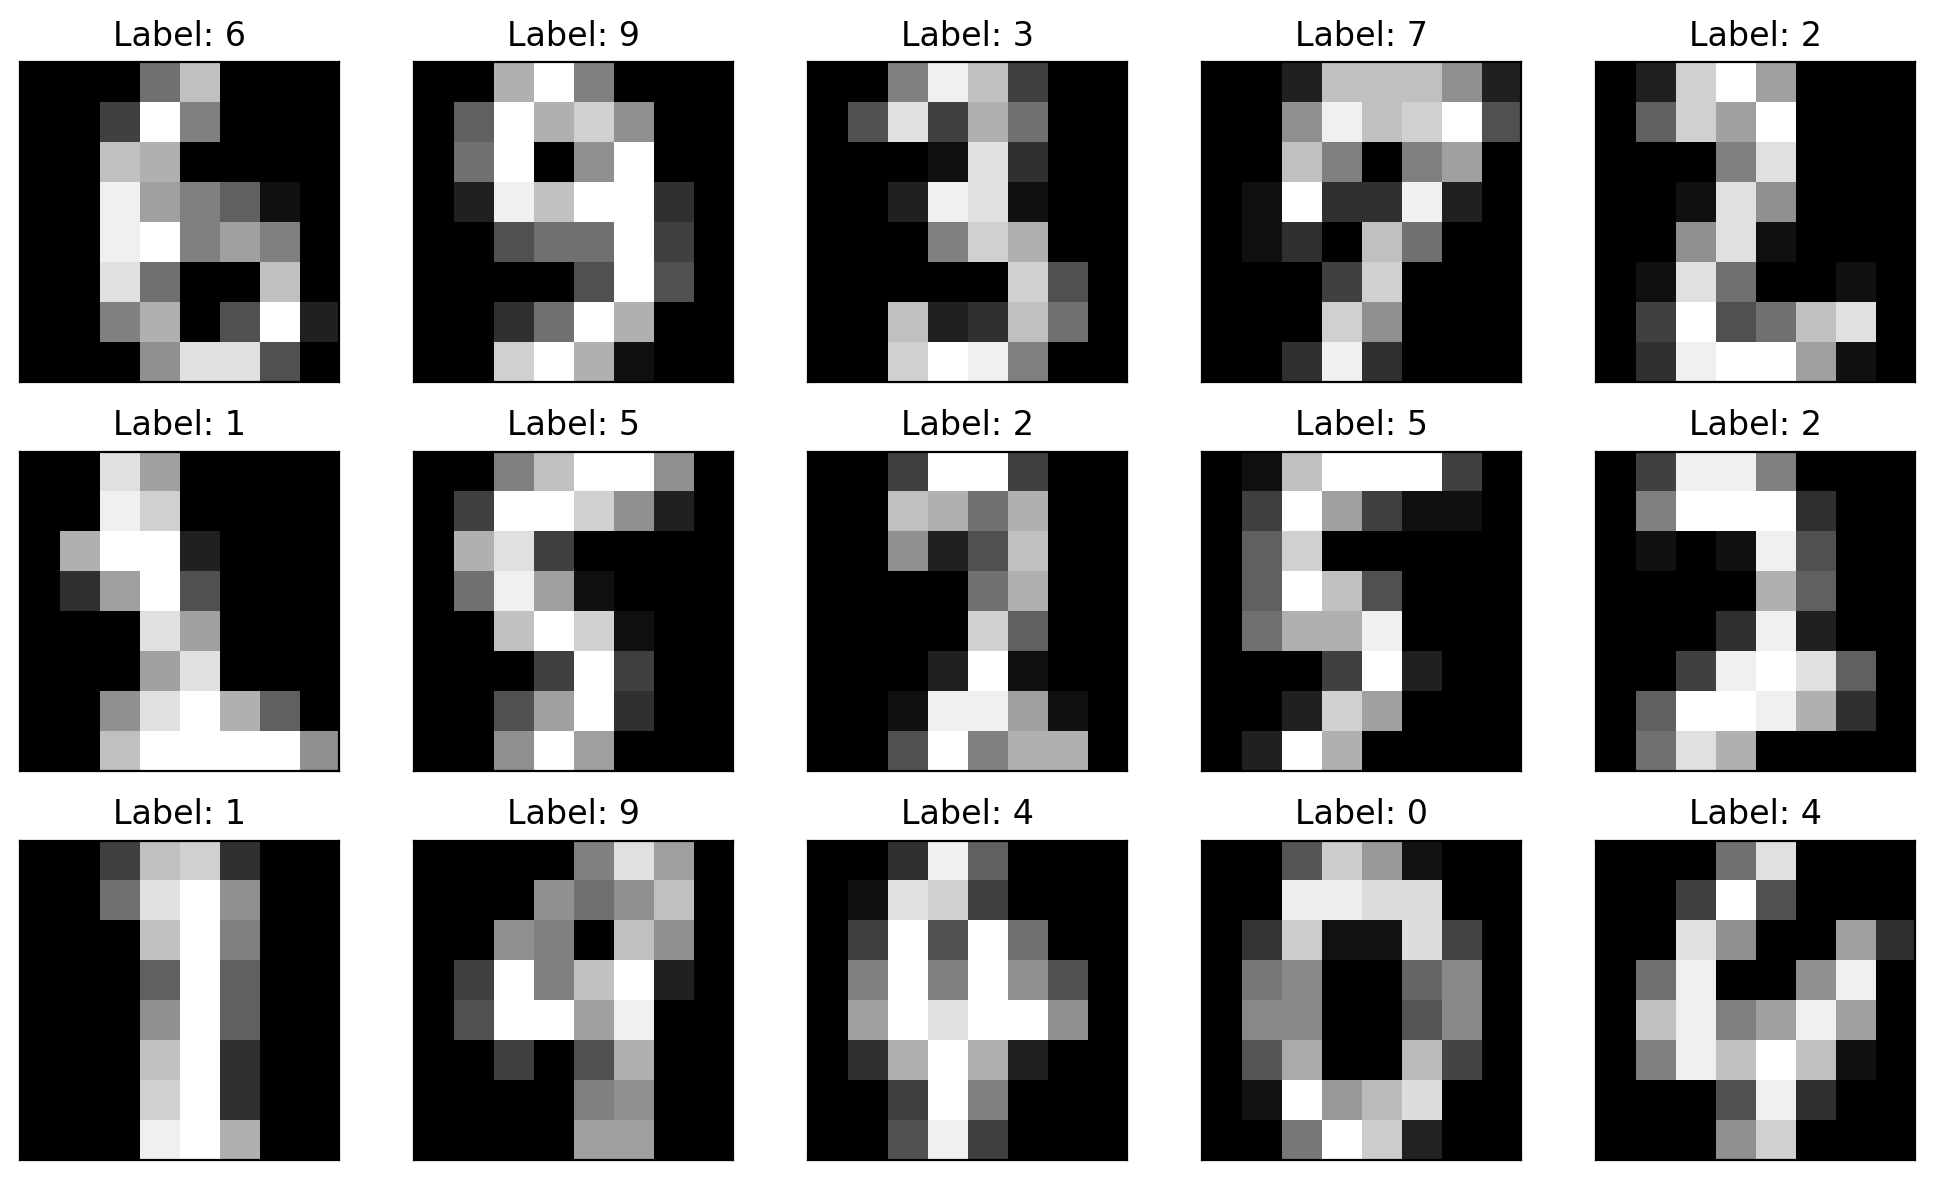

In [26]:
visualize_digits(X, y, n_samples=15)


## ML PPCA
Compute ML estimates using spectral decomposition and project the data to a lower-dimensional space.




In [27]:
# === Task 2: Maximum Likelihood PPCA Implementation ===

def ML_ppca(X, M):
    """
    Perform ML PPCA via spectral decomposition.

    Args:
        X: (N, D) dataset
        M: Latent dimension

    Returns:
        Z: (N, M) posterior projection E[z|x]
        W_ml: (D, M) weight matrix
        sigma2_ml: noise variance scalar
        mu_ml: (D,) mean vector
        evals: eigenvalues of sample covariance
    """
    N, D = X.shape

    # Compute sample mean
    mu_ML = np.mean(X, axis=0)
    X_centered = X - mu_ML

    # a.Compute sample covariance matrix S
    S = np.cov(X_centered, rowvar=False, bias=True)

    # b.Spectral decomposition
    evals, evecs = eigh(S)

    # Sort eigenvalues and eigenvectors in descending order
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Extract top M eigenvalues and eigenvectors
    # U_M: (D, M), L_M: (M, M) diagonal
    U_M = evecs[:, :M]
    Lambda_M = np.diag(evals[:M])

    # c. Compute sigma^2_ML and W_ML
    # sigma^2 is the average of the discarded eigenvalues (from M+1 to D)
    if M < D:
        sigma2_ML = np.mean(evals[M:])
    else:
        sigma2_ML = 0.0

    # W_ML = U_M * (L_M - sigma^2 * I)^(1/2) * R (Let R=I)
    # Use maximum to prevent negative values due to numerical float errors
    diff_matrix = Lambda_M - sigma2_ML * np.eye(M)
    diff_matrix[diff_matrix < 0] = 0 # incase rasing error
    W_ML = U_M @ np.sqrt(diff_matrix)

    # d. Compute posterior projection E[z|x]
    # Formula: E[z|x] = (W^T W + sigma^2 I)^-1 W^T (x - mu)
    # M_matrix is the M x M matrix to be inverted
    M_matrix = W_ML.T @ W_ML + sigma2_ML * np.eye(M)

    # Use pseudo-inverse if determinant is too close to zero (stability)
    try:
        M_inv = inv(M_matrix)
    except np.linalg.LinAlgError:
        M_inv = np.linalg.pinv(M_matrix)

    Z = (M_inv @ W_ML.T @ X_centered.T).T

    return Z, W_ML, sigma2_ML, mu_ML

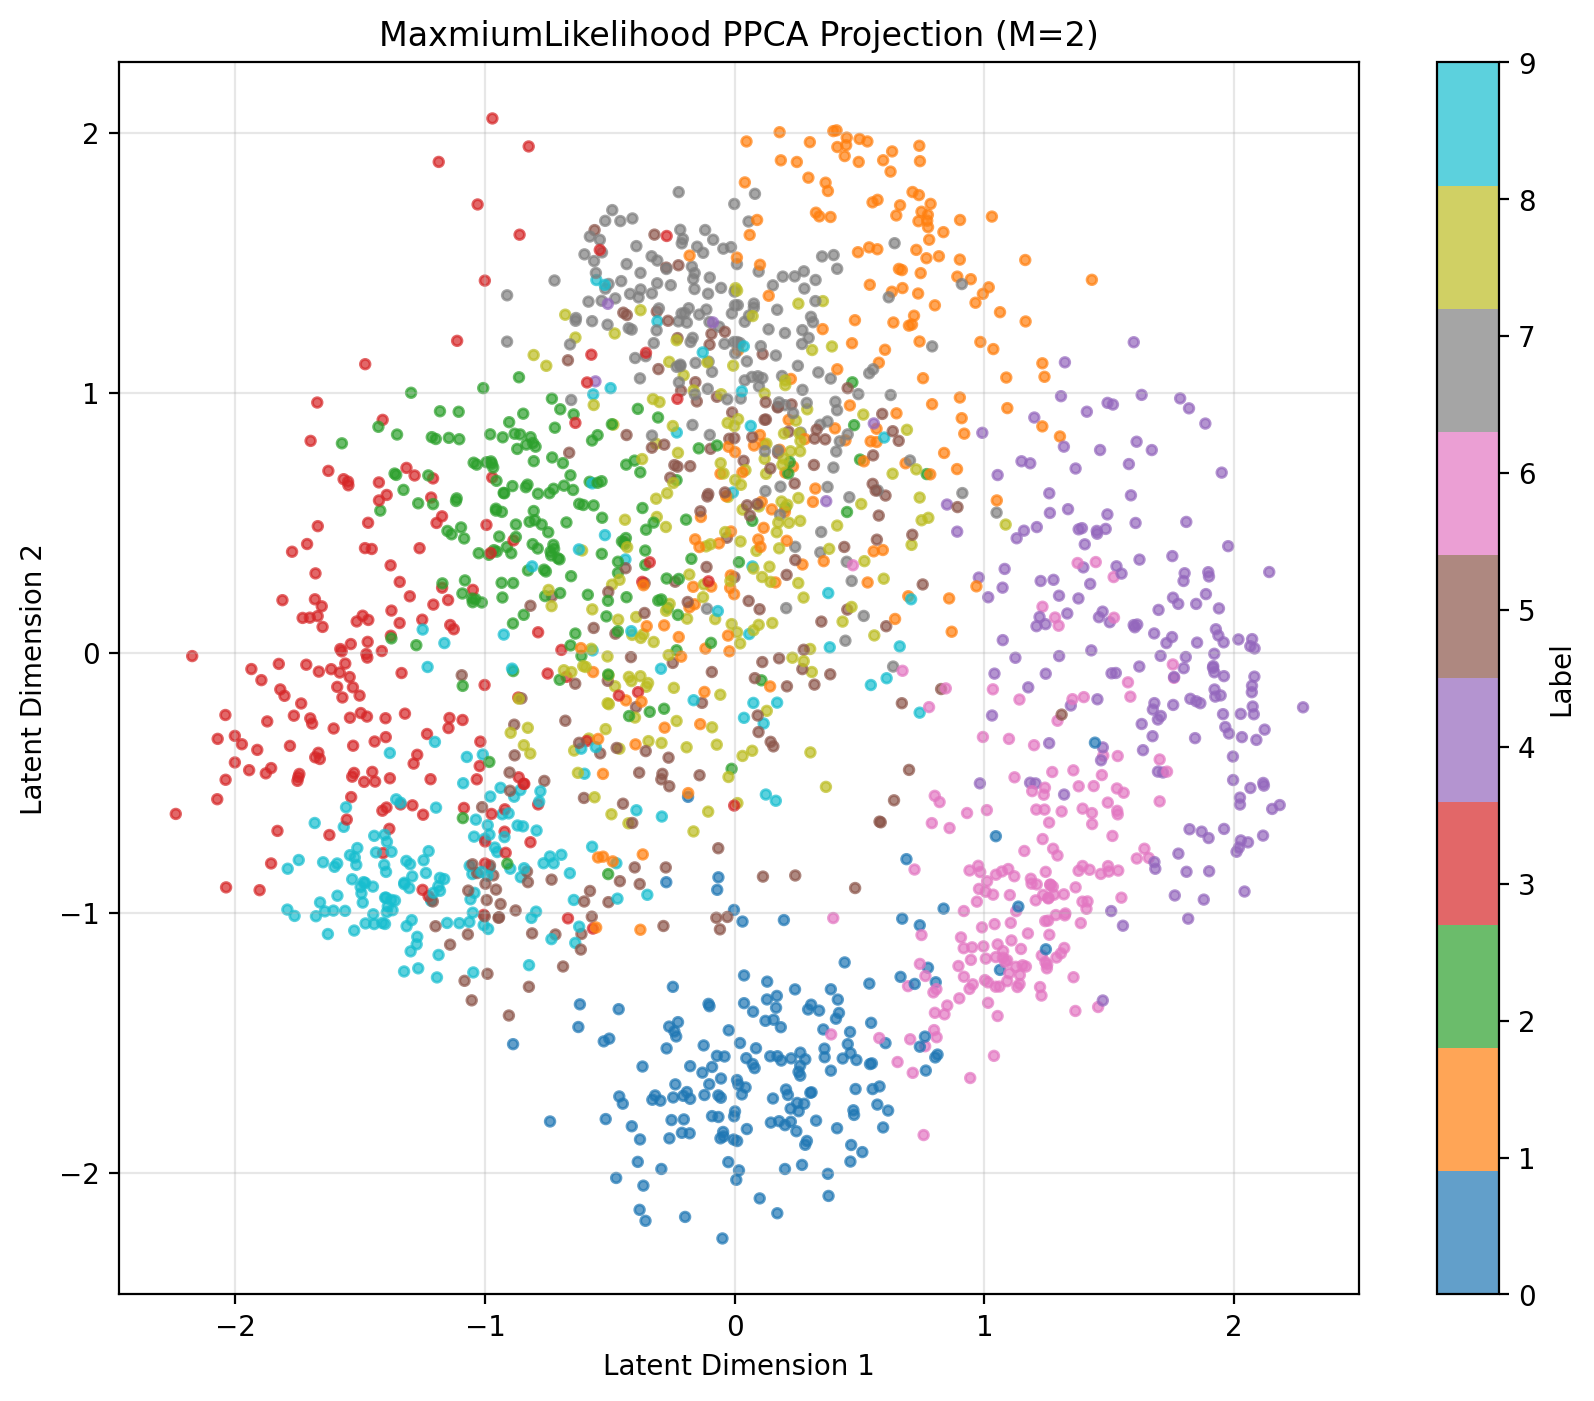

In [28]:
# Visualization for Task 2 (M=2)
Z_ML, W_ML, sigma2_ML, mu_ML = ML_ppca(Xtrain, M=2)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(Z_ML[:, 0], Z_ML[:, 1], c=ytrain, cmap='tab10', s=12, alpha=0.7)
plt.colorbar(scatter, label='Label')
plt.title('MaxmiumLikelihood PPCA Projection (M=2)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()


## EM Algorithm Implementation for PPCA




<>:156: SyntaxWarning: invalid escape sequence '\s'
<>:156: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1928466374.py:156: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'EM PPCA Projection (M=2)\nFinal $\sigma^2$ = {em_ppca.sigma2:.4f}')



Running EM PPCA with M=2...
The diff of each iteration
Iter 0: diff = 25112799.414549023
Iter 1: diff = 2094.94732342544
Iter 2: diff = 687.1429882859229
Iter 3: diff = 431.00845500983996
Iter 4: diff = 333.33107207296416
Iter 5: diff = 268.11516828043386
Iter 6: diff = 210.08784871798707
Iter 7: diff = 157.68893278867472
Iter 8: diff = 113.82244179601548
Iter 9: diff = 79.81470971857198
Iter 10: diff = 54.924223816837184
Iter 11: diff = 37.39199662109604
Iter 12: diff = 25.33025143807754
Iter 13: diff = 17.140716100868303
Iter 14: diff = 11.614922088803723
Iter 15: diff = 7.893076129956171
Iter 16: diff = 5.383711378730368
Iter 17: diff = 3.6872604897944257
Iter 18: diff = 2.5361750147421844
Iter 19: diff = 1.7518806486623362
Iter 20: diff = 1.2151620783261023
Iter 21: diff = 0.8462495959829539
Iter 22: diff = 0.5915809418656863
Iter 23: diff = 0.4150416176998988
Iter 24: diff = 0.29217221547150984
Iter 25: diff = 0.20633091701893136
Iter 26: diff = 0.1461430480121635
Iter 27: diff =

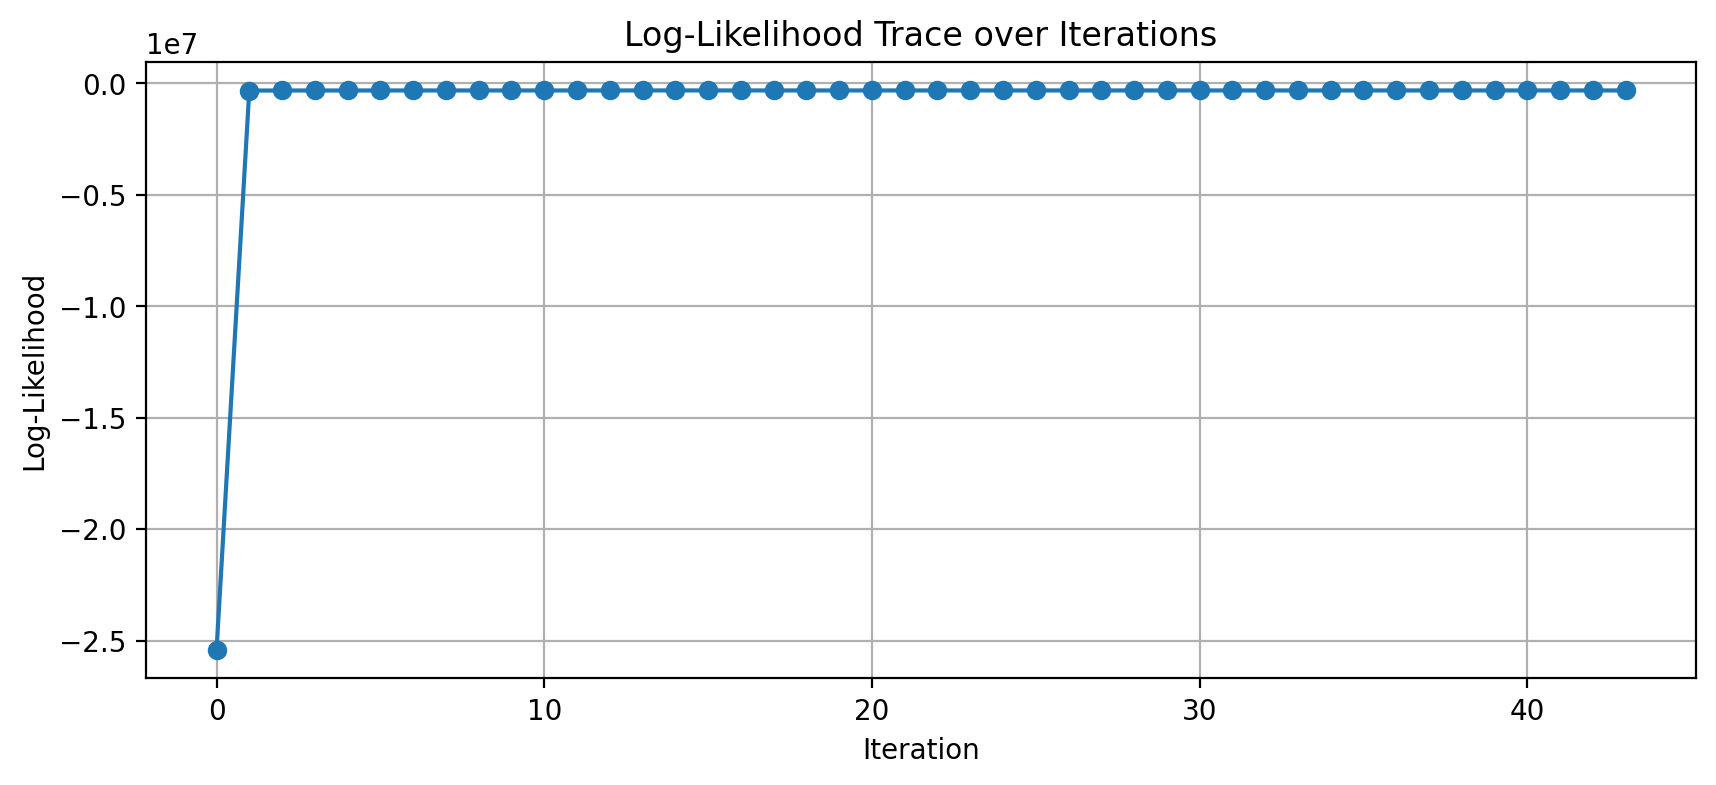

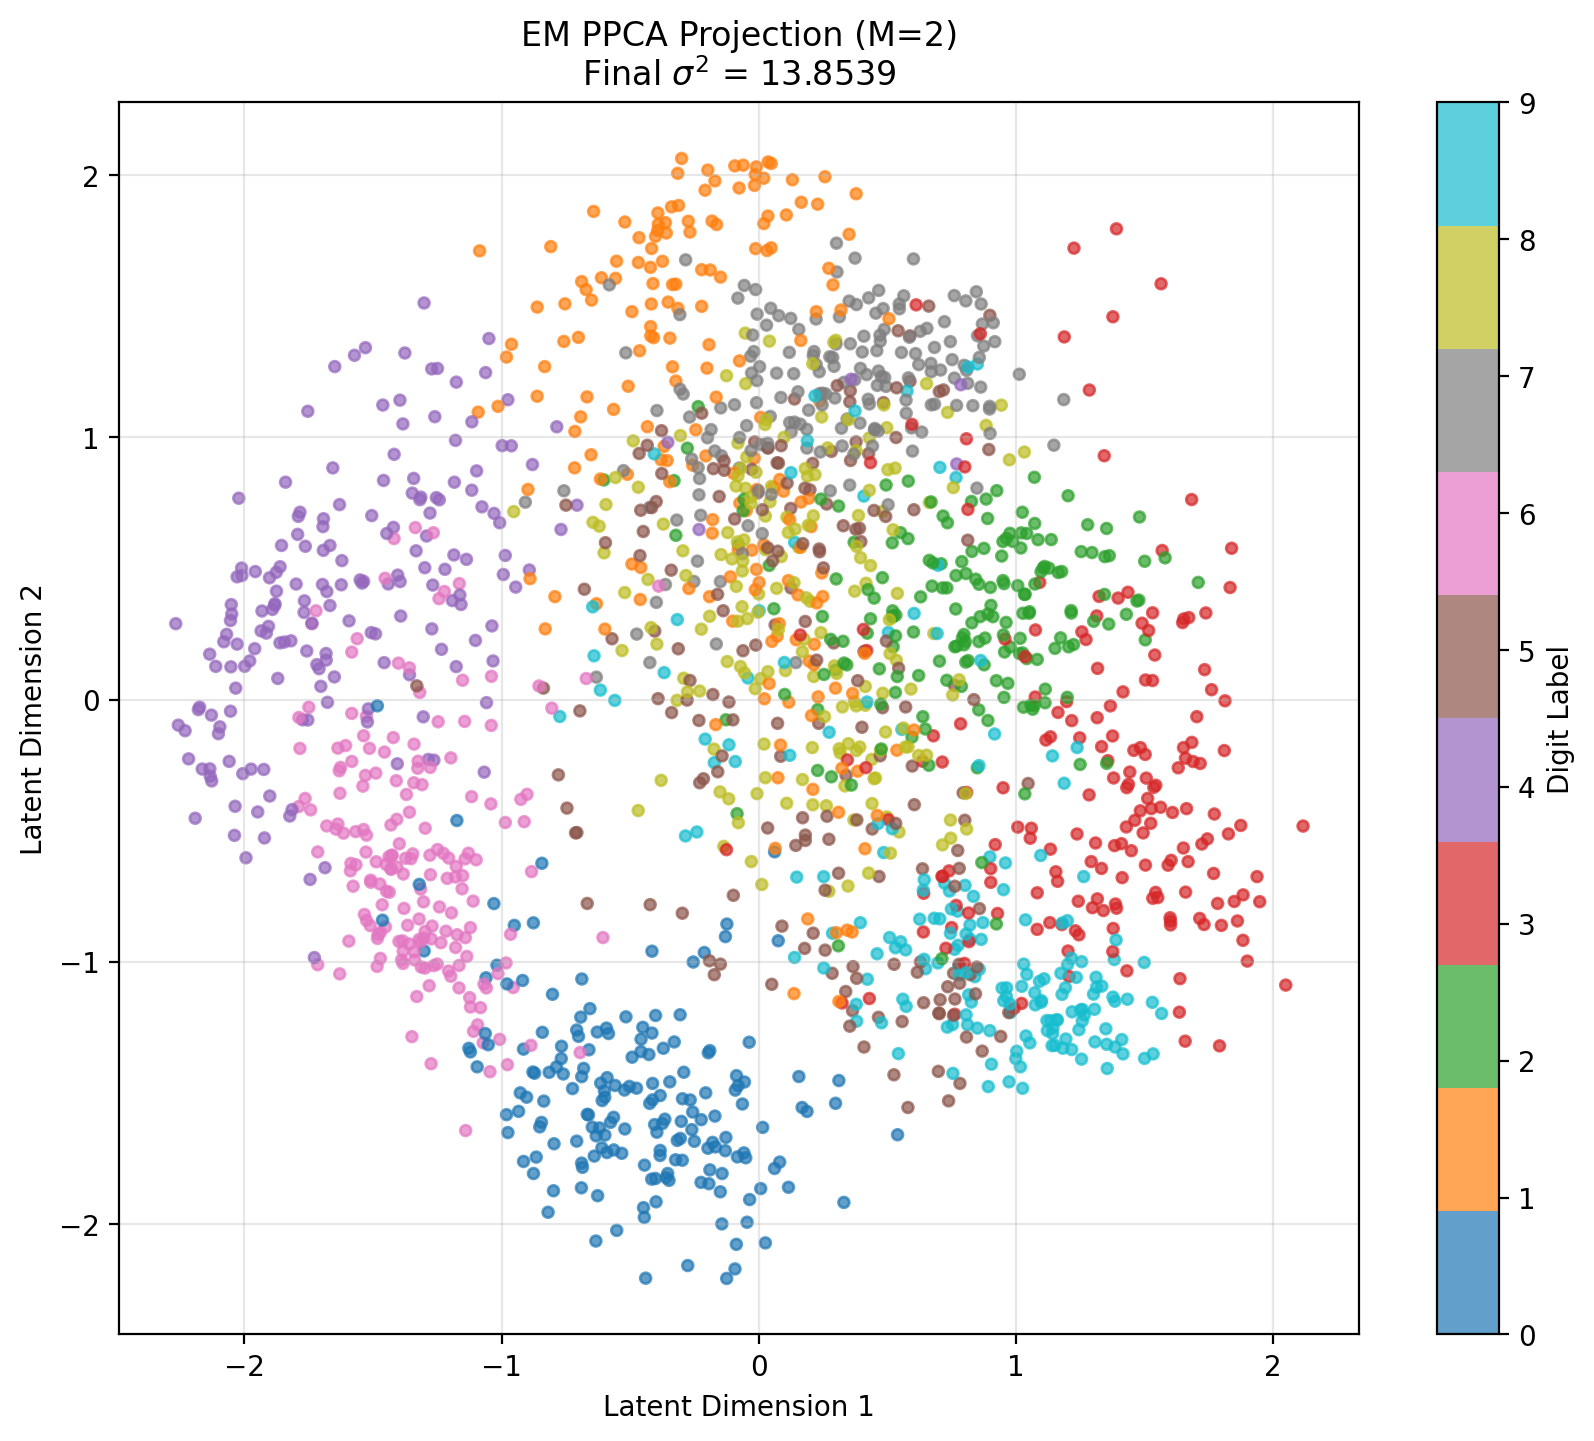

In [40]:
# Task 3: EM Algorithm for PPCA Implementation

class PPCA_EM:
    def __init__(self, M, max_iter=30, threshold=1e-3, seed=42):
        self.M = M
        self.max_iter = max_iter
        self.threshold = threshold
        self.seed = seed
        self.W = None
        self.sigma2 = None
        self.mu = None
        self.log_likelihood_history = []

    def init_params(self, D):
        if self.seed is not None:
            np.random.seed(self.seed)

        # Initialize W
        self.W = np.random.normal(0, 1.0, size=(D, self.M))

        # Initialize sigma^2
        self.sigma2 = np.random.uniform(0, 1.0)

    def _compute_log_likelihood(self, X_centered):
        N, D = X_centered.shape
        # C = W W^T + sigma^2 I is a (D, D) matrix
        C = self.W @ self.W.T + self.sigma2 * np.eye(D)

        # ln P(X) = -1/2 * (NDlog(2pi) + N*log(det(C)) + sum(xiT*C^-1*xi))
        try:
            # Using Cholesky for stability in det and inv if possible, otherwise standard
            sign, logdet = np.linalg.slogdet(C)
            if sign != 1:
                # Fallback if matrix is not positive definite due to numerical errors
                logdet = np.log(np.abs(det(C)))

            # Tr(C^-1 S) = Tr(C^-1 * (X^T X / N)) = 1/N * Tr(C^-1 X^T X) = 1/N * Sum(Row_i(X @ C^-1) dot Row_i(X))
            # Actually simpler: Sum over n ( (x_n-mu)^T C^-1 (x_n-mu) )
            C_inv = inv(C)
            # Mahalanobis distance sum
            mahalanobis = np.sum((X_centered @ C_inv) * X_centered)

            ll = -0.5 * (N * D * np.log(2 * np.pi) + N * logdet + mahalanobis)
            return ll
        except:
            return -np.inf

    def fit(self, X):
        N, D = X.shape
        self.mu = np.mean(X, axis=0)
        X_centered = X - self.mu

        # ||x_n - mu||^2
        X_norm_sq_sum = np.sum(X_centered**2)

        self.init_params(D)
        self.log_likelihood_history = []

        # Initial Log Likelihood
        ll = self._compute_log_likelihood(X_centered)
        self.log_likelihood_history.append(ll)

        print("The diff of each iteration")
        orint('=' * 50)
        for i in range(self.max_iter):
            prev_ll = ll

            # --- E-Step ---
            # Compute M = W^T W + sigma^2 I （M, M)
            M_mat = self.W.T @ self.W + self.sigma2 * np.eye(self.M)
            try:
                M_inv = inv(M_mat)
            except:
                M_inv = np.linalg.pinv(M_mat)

            # E[z_n] = M^-1 W^T (x_n - mu)
            # Dimension: (M, M) @ (M, D) @ (D, N) -> (M, N). Transpose to (N, M)
            Ez = (M_inv @ self.W.T @ X_centered.T).T

            # E[z_n z_n^T] sum over N
            # Sum E[z_n z_n^T] = N * sigma^2 * M^-1 + Sum(Ez_n * Ez_n^T)
            # Ez.T @ Ez performs the summation of outer products
            Sum_Ezz = N * self.sigma2 * M_inv + Ez.T @ Ez

            # --- M-Step ---
            # W_new = (Sum (x_n - mu)E[z_n]^T) @ (Sum E[z_n z_n^T])^-1
            # Numerator: (D, N) @ (N, M) -> (D, M)
            W_numerator = X_centered.T @ Ez

            try:
                W_new = W_numerator @ inv(Sum_Ezz)
            except:
                W_new = W_numerator @ np.linalg.pinv(Sum_Ezz)

            # sigma^2_new
            # Term 1: Sum ||x - mu||^2 (precomputed X_norm_sq_sum)
            # Term 2: -2 * Tr(E[z]^T W^T (x - mu)) -> can be written as -2 * Sum(Ez * (xW)_n)
            # Term 3: Tr(Sum E[zz] W^T W)

            # Efficient computation for Term 2:
            # Trace(Ez^T @ W_new.T @ X_centered.T) = Sum_elements( (Ez @ W_new.T) * X_centered )
            term2 = -2 * np.sum((Ez @ W_new.T) * X_centered) # Element-wise mult then sum

            # Efficient computation for Term 3:
            term3 = np.trace(W_new.T @ W_new @ Sum_Ezz)

            sigma2_new = (X_norm_sq_sum + term2 + term3) / (N * D)

            # Update parameters
            self.W = W_new
            self.sigma2 = max(sigma2_new, 1e-10) # Prevent zero/negative variance

            # --- Check Convergence ---
            ll = self._compute_log_likelihood(X_centered)
            self.log_likelihood_history.append(ll)

            print(f"Iter {i}: diff = {abs(ll - prev_ll)}")
            if ll < prev_ll:
              print('Haing mistake')
              break
            if abs(ll - prev_ll) < self.threshold:
              print('='*50)
              print(f"Converged at iteration {i+1}")
              break

        return self.transform(X)



    def transform(self, X):
        X_centered = X - self.mu
        M_mat = self.W.T @ self.W + self.sigma2 * np.eye(self.M)
        try:
            M_inv = inv(M_mat)
        except:
            M_inv = np.linalg.pinv(M_mat)
        return (M_inv @ self.W.T @ X_centered.T).T

# Visualization for Task 3
print("\nRunning EM PPCA with M=2...")
em_ppca = PPCA_EM(M=2, max_iter=60, threshold=1e-3, seed=42)
Z_em = em_ppca.fit(Xtrain)

# Plot Trace
plt.figure(figsize=(10, 4))
plt.plot(em_ppca.log_likelihood_history, 'o-')
plt.title('Log-Likelihood Trace over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Log-Likelihood')
plt.grid(True)
plt.show()

# Plot Projection
plt.figure(figsize=(10, 8))
scatter = plt.scatter(Z_em[:, 0], Z_em[:, 1], c=ytrain, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='Digit Label')
plt.title(f'EM PPCA Projection (M=2)\nFinal $\sigma^2$ = {em_ppca.sigma2:.4f}')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True, alpha=0.3)
plt.show()

## Task4

The following code show example how to using standard PCA extract the latent embeddings and project the latent embeddings using t-SNE.

In [41]:
import time
from sklearn.decomposition import PCA

def run_pca_once(X, n_comp):
    """
    Run PCA once and return running time and results
    """
    start_time = time.time()
    pca = PCA(n_components=n_comp)
    Z = pca.fit_transform(X)
    end_time = time.time()
    return end_time - start_time, pca, Z

def compare_svd_pca_components(X, y, components_list=[2, 5, 10, 20], n_runs=3):
    """
    Compare PCA results with different numbers of components using SVD

    Parameters:
    -----------
    X : array-like
        Input data
    y : array-like
        Labels for coloring
    components_list : list
        List of n_components to try
    n_runs : int
        Number of times to run each PCA for timing
    """
    # Create subplot grid with 5 plots per row
    n_plots = len(components_list)
    n_cols = 5
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig = plt.figure(figsize=(20, 4*n_rows))
    gs = plt.GridSpec(n_rows, n_cols+1, width_ratios=[1]*n_cols + [0.05])

    # Initialize t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)

    # Record running times
    running_times = []
    running_times_std = []  # Standard deviation of running times
    #Record variance explained
    var_explaineds = []

    # Create axes for plots
    axes = []
    for i in range(n_plots):
        row = i // n_cols
        col = i % n_cols
        axes.append(plt.subplot(gs[row, col]))

    for idx, (ax, n_comp) in enumerate(zip(axes, components_list)):
        # Run PCA multiple times
        times = []
        for _ in range(n_runs):
            time_taken, pca, Z = run_pca_once(X, n_comp)
            times.append(time_taken)

        # Calculate mean and std of running times
        mean_time = np.mean(times)
        std_time = np.std(times)
        running_times.append(mean_time)
        running_times_std.append(std_time)

        # Use last PCA result for visualization
        if n_comp > 2:
            Z_2d = tsne.fit_transform(Z)
        else:
            Z_2d = Z

        # Plot
        scatter = ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c=y, cmap='tab10', s=10)
        explained_var = np.sum(pca.explained_variance_ratio_) * 100
        var_explaineds.append(explained_var)
        ax.set_title(f'Standard-PCA (n={n_comp})\nVar: {explained_var:.1f}%\nTime: {mean_time:.3f}±{std_time:.3f}s')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')

    # Add colorbar in a separate axis
    cbar_ax = plt.subplot(gs[:, -1])
    plt.colorbar(scatter, cax=cbar_ax)

    plt.tight_layout()
    plt.show()

    # Print detailed results
    print("\nDetailed results:")
    print(f"{'n_components':<12} {'Time (s)':<15} {'Std Dev':<10} {'Variance Explained':<20}")
    print("-" * 57)
    for n_comp, mean_time, std_time, var_explained in zip(components_list, running_times, running_times_std, var_explaineds):

        print(f"{n_comp:<12} {mean_time:<15.3f} {std_time:<10.3f} {var_explained:<20.2f}%")

    # Plot running times with error bars
    plt.figure(figsize=(10, 5))
    plt.errorbar(components_list, running_times, yerr=running_times_std,
                fmt='o-', linewidth=2, markersize=8, capsize=5)
    plt.xlabel('Number of Components')
    plt.ylabel('Running Time (seconds)')
    plt.title(f'PCA Running Time vs Number of Components\n(Average of {n_runs} runs with std dev)')
    plt.grid(True)
    plt.show()

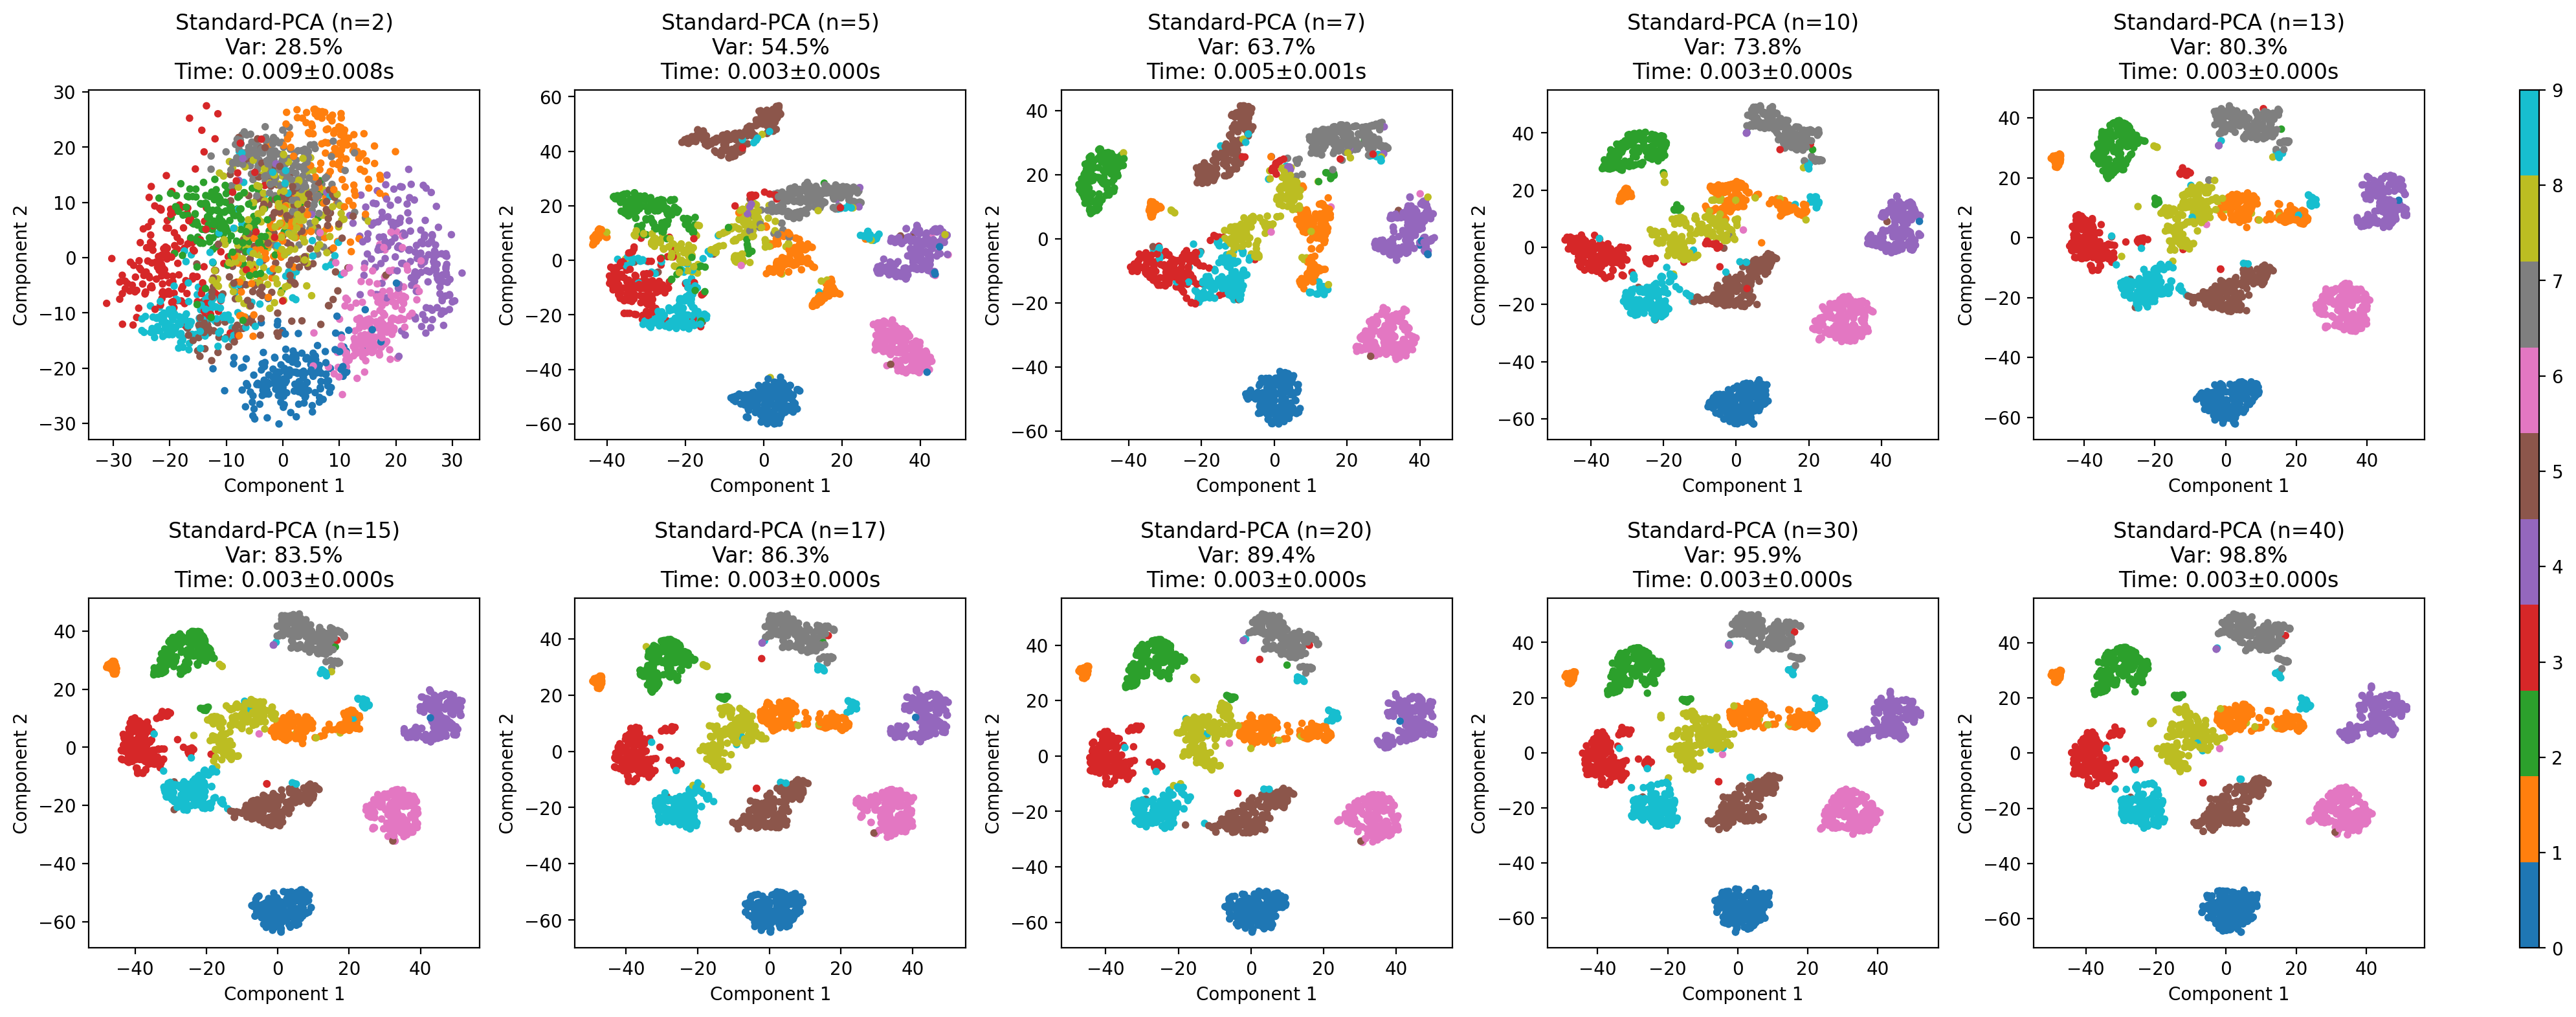


Detailed results:
n_components Time (s)        Std Dev    Variance Explained  
---------------------------------------------------------
2            0.009           0.008      28.51               %
5            0.003           0.000      54.50               %
7            0.005           0.001      63.73               %
10           0.003           0.000      73.82               %
13           0.003           0.000      80.29               %
15           0.003           0.000      83.53               %
17           0.003           0.000      86.26               %
20           0.003           0.000      89.43               %
30           0.003           0.000      95.91               %
40           0.003           0.000      98.82               %


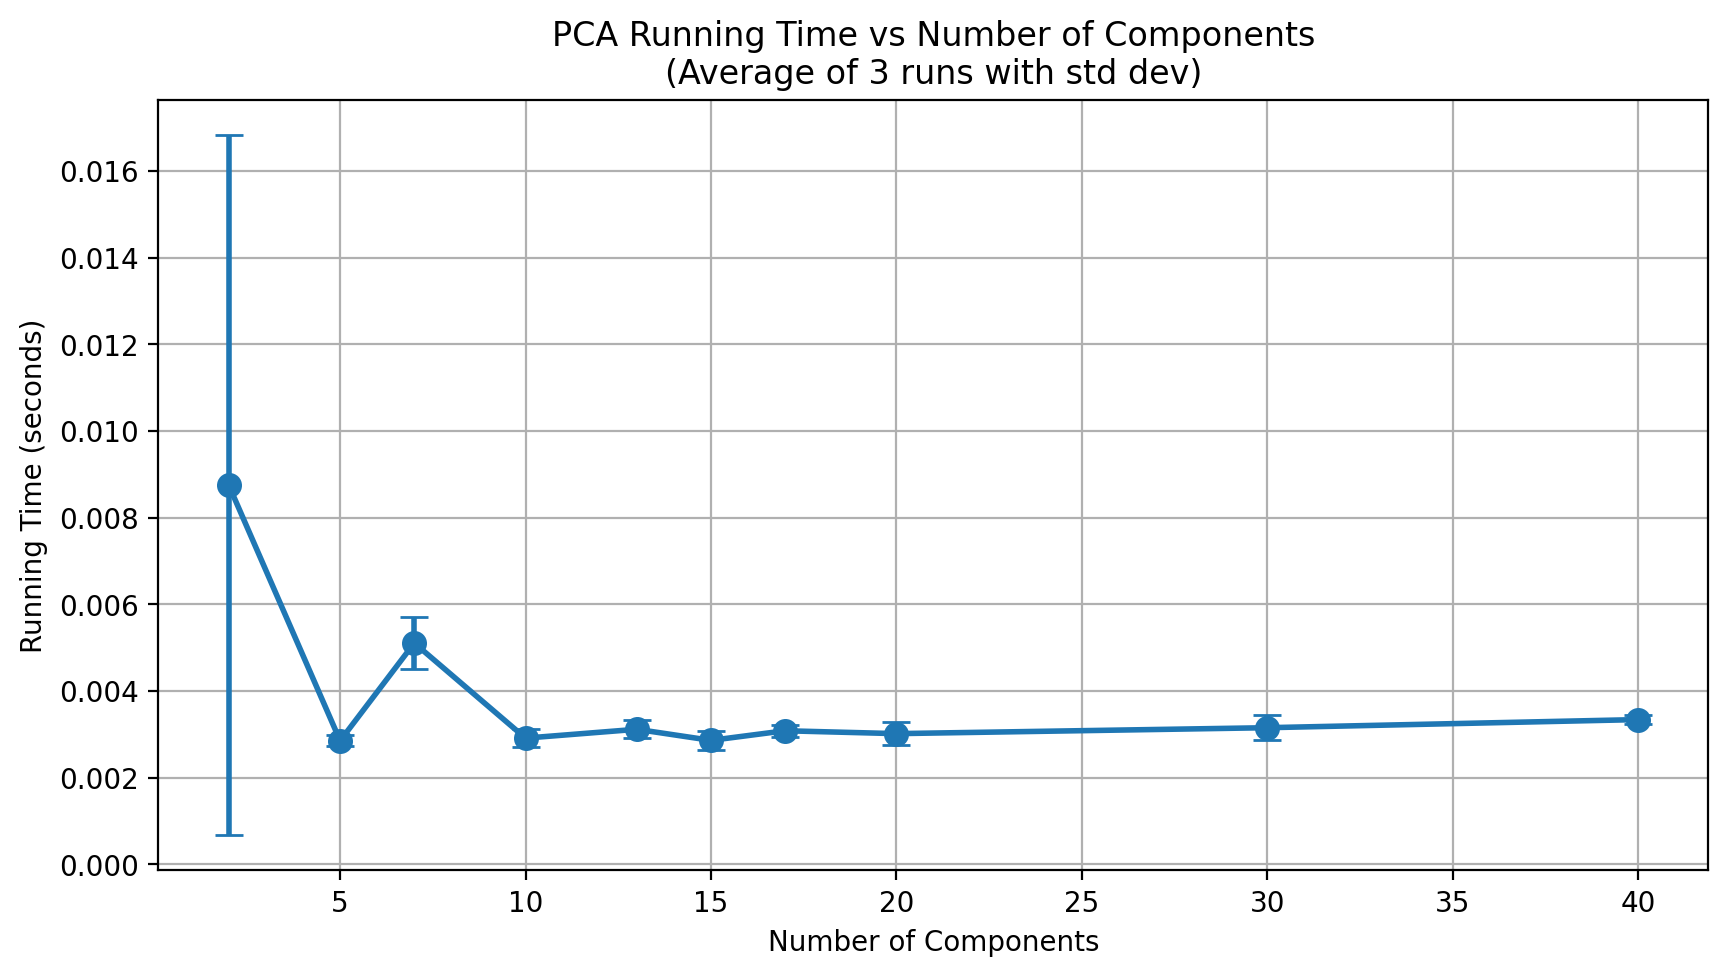

In [42]:

components_to_try = [2,  5,  7, 10, 13, 15, 17, 20, 30, 40,]
compare_svd_pca_components(X, y, components_to_try, n_runs=3)

### ML PPCA

In the following part, your just need to using your implementation of ML PPCA to extract the latent embedding Z in function `run_mlppca_once`

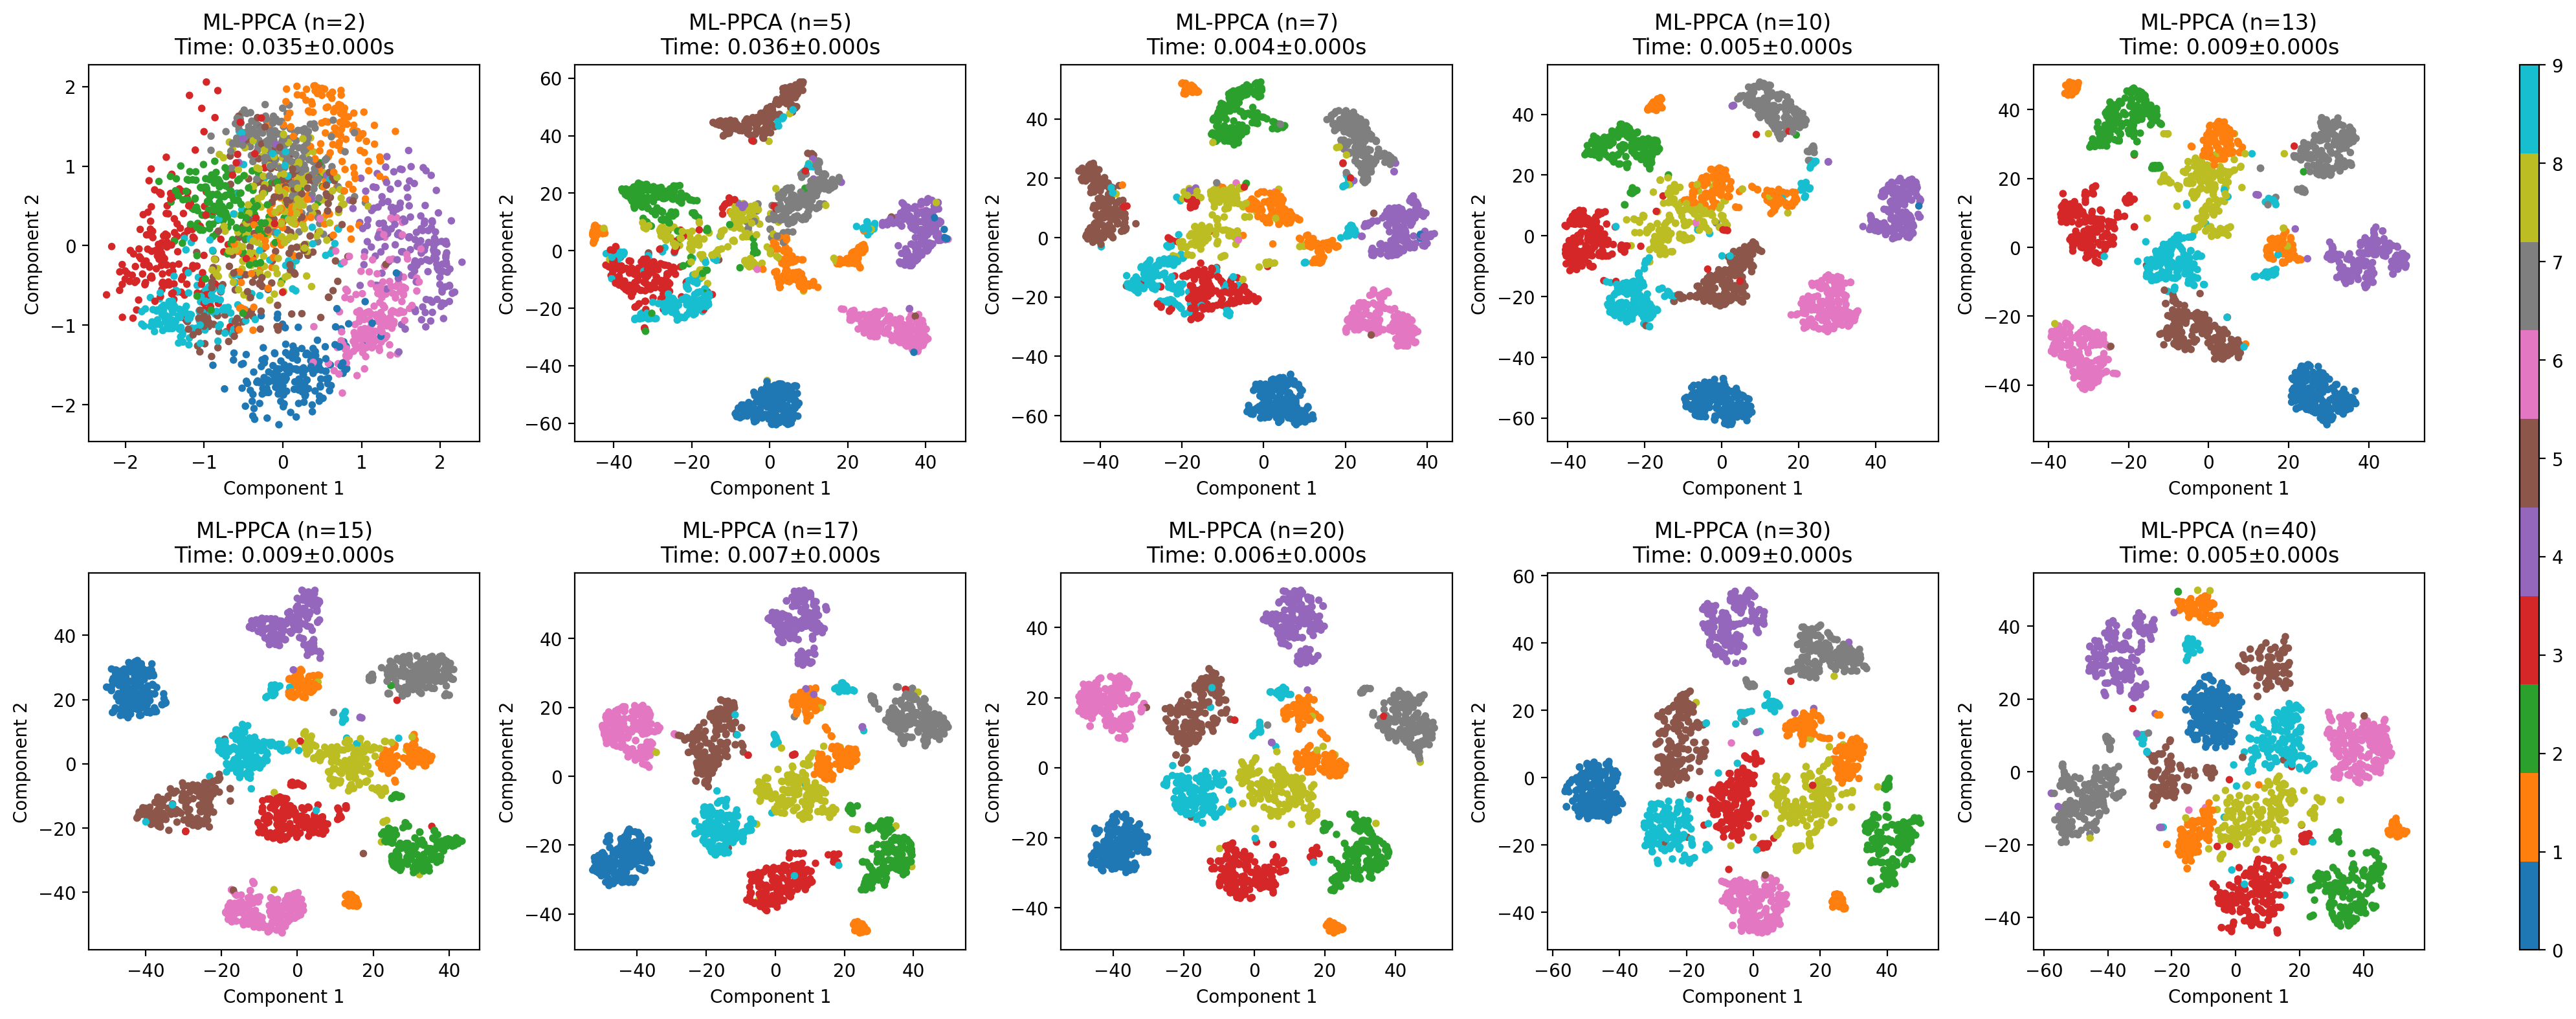


Detailed results:
n_components Time (s)        Std Dev   
-------------------------------------
2            0.035           0.000     
5            0.036           0.000     
7            0.004           0.000     
10           0.005           0.000     
13           0.009           0.000     
15           0.009           0.000     
17           0.007           0.000     
20           0.006           0.000     
30           0.009           0.000     
40           0.005           0.000     


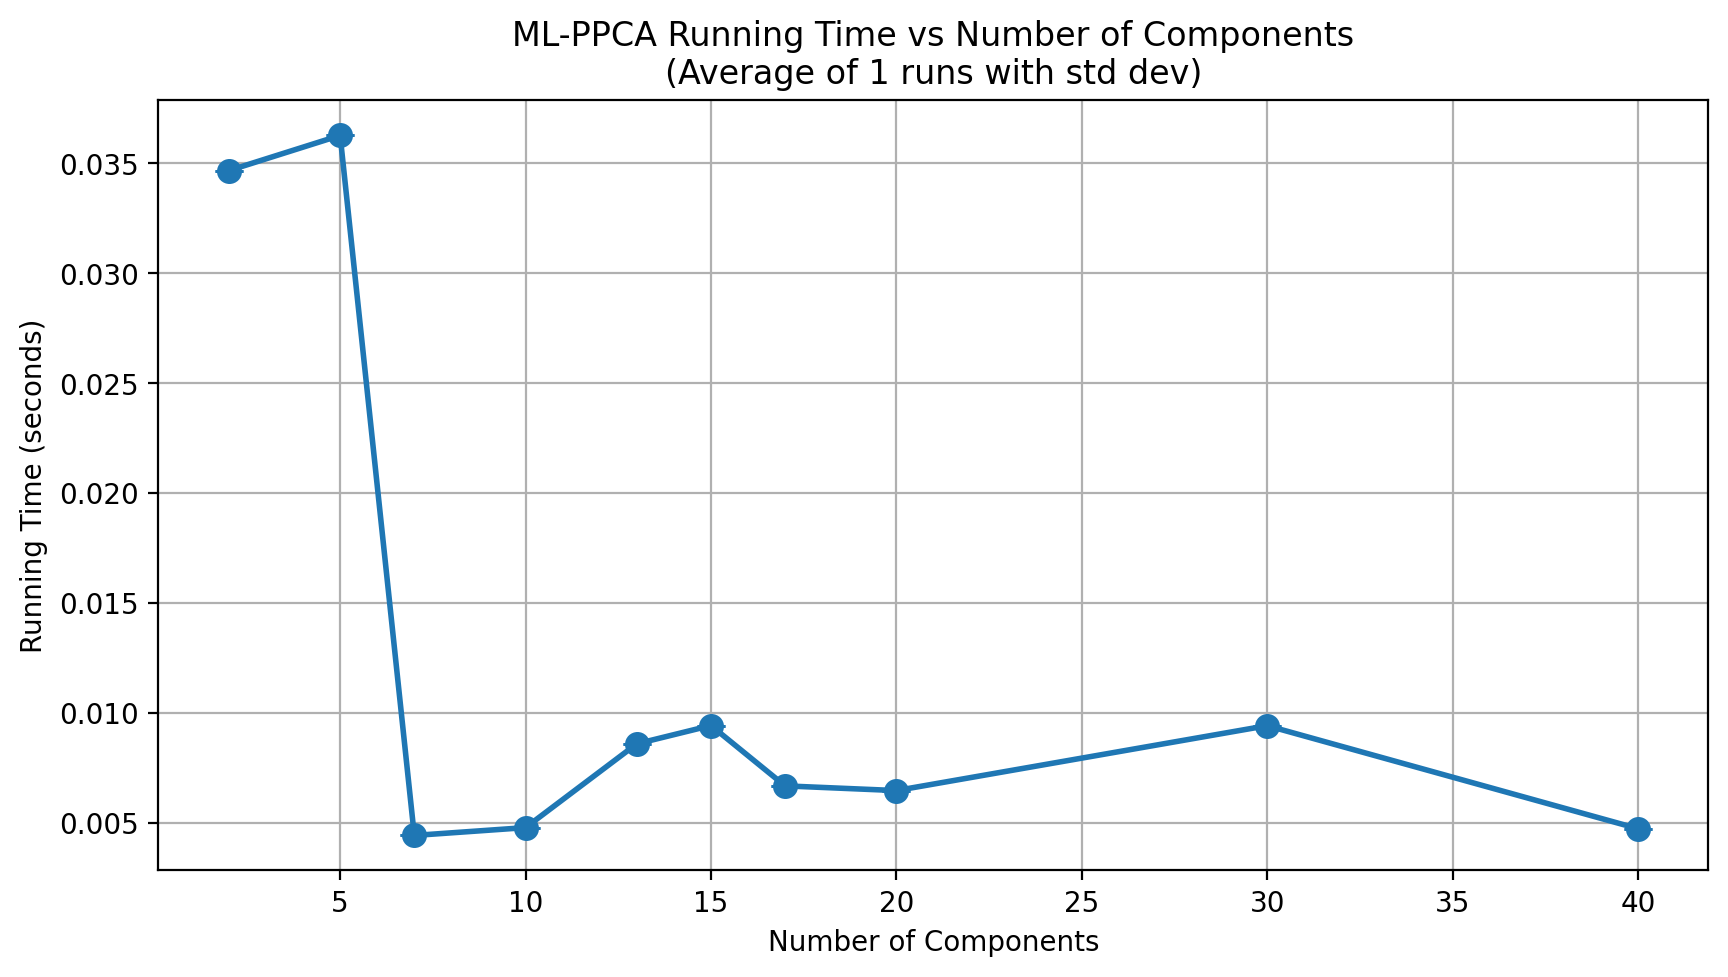

In [43]:
def run_mlppca_once(X, n_comp):
    """
    Run ML-PPCA once and return running time and results

    Parameters:
    -----------
    X : array-like
        Input data
    n_comp : int
        Number of components

    Returns:
    --------
    time_taken : float
        Running time in seconds
    Z : array-like
        Transformed data
    """
    start_time = time.time()

    N, D = X.shape
    mu = np.mean(X, axis=0)
    X_centered = X - mu
    S = np.cov(X_centered, rowvar=False, bias=True)
    evals, evecs = eigh(S)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    U_M = evecs[:, :n_comp]
    L_M = np.diag(evals[:n_comp])

    if n_comp < D:
        sigma2 = np.mean(evals[n_comp:])
    else:
        sigma2 = 0.0

    diff = L_M - sigma2 * np.eye(n_comp)
    diff[diff < 0] = 0
    W = U_M @ np.sqrt(diff)

    M_mat = W.T @ W + sigma2 * np.eye(n_comp)
    try:
        M_inv = inv(M_mat)
    except:
        M_inv = np.linalg.pinv(M_mat)

    Z = (M_inv @ W.T @ X_centered.T).T
    end_time = time.time()

    return end_time - start_time, Z

def compare_mlpca_components(X, y, components_list=[2, 5, 10, 20], n_runs=3):
    """
    Compare ML-PPCA results with different numbers of components

    Parameters:
    -----------
    X : array-like
        Input data
    y : array-like
        Labels for coloring
    components_list : list
        List of n_components to try
    n_runs : int
        Number of times to run each PPCA for timing
    """
    # Create subplot grid with 5 plots per row
    n_plots = len(components_list)
    n_cols = 5
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig = plt.figure(figsize=(20, 4*n_rows))
    gs = plt.GridSpec(n_rows, n_cols+1, width_ratios=[1]*n_cols + [0.05])

    # Initialize t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)

    # Record running times
    running_times = []
    running_times_std = []  # Standard deviation of running times

    # Create axes for plots
    axes = []
    for i in range(n_plots):
        row = i // n_cols
        col = i % n_cols
        axes.append(plt.subplot(gs[row, col]))

    for idx, (ax, n_comp) in enumerate(zip(axes, components_list)):
        # Run ML-PPCA multiple times
        times = []
        for _ in range(n_runs):
            time_taken, Z = run_mlppca_once(X, n_comp)
            times.append(time_taken)

        # Calculate mean and std of running times
        mean_time = np.mean(times)
        std_time = np.std(times)
        running_times.append(mean_time)
        running_times_std.append(std_time)

        # Use last PPCA result for visualization
        if n_comp > 2:
            Z_2d = tsne.fit_transform(Z)
        else:
            Z_2d = Z

        # Plot
        scatter = ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c=y, cmap='tab10', s=10)
        ax.set_title(f'ML-PPCA (n={n_comp})\nTime: {mean_time:.3f}±{std_time:.3f}s')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')

    # Add colorbar in a separate axis
    cbar_ax = plt.subplot(gs[:, -1])
    plt.colorbar(scatter, cax=cbar_ax)

    plt.tight_layout()
    plt.show()

    # Print detailed results
    print("\nDetailed results:")
    print(f"{'n_components':<12} {'Time (s)':<15} {'Std Dev':<10}")
    print("-" * 37)
    for n_comp, mean_time, std_time in zip(components_list, running_times, running_times_std):
        print(f"{n_comp:<12} {mean_time:<15.3f} {std_time:<10.3f}")

    # Plot running times with error bars
    plt.figure(figsize=(10, 5))
    plt.errorbar(components_list, running_times, yerr=running_times_std,
                fmt='o-', linewidth=2, markersize=8, capsize=5)
    plt.xlabel('Number of Components')
    plt.ylabel('Running Time (seconds)')
    plt.title(f'ML-PPCA Running Time vs Number of Components\n(Average of {n_runs} runs with std dev)')
    plt.grid(True)
    plt.show()

components_to_try = [2, 5, 7, 10, 13, 15, 17, 20, 30, 40]
# set n_runs to 1 for debugging; set n_runs to 3 for final submission
compare_mlpca_components(X, y, components_to_try, n_runs=1)

### EM PPCA

In the following code, you just need to use your implement of EM PPCA to extract the latent embedding Z and record the log-likelihood values during iterations in function `run_ppca_em_once`

In [ ]:
def run_ppca_em_once(X, n_comp, n_iter=30, seed=None):
    """
    Run PPCA EM algorithm once and return running time and results

    Parameters:
    -----------
    X : array-like
        Input data
    n_comp : int
        Number of components
    n_iter : int
        Number of EM iterations
    seed : int
        Random seed for initialization

    Returns:
    --------
    time_taken : float
        Running time in seconds
    Z : array-like
        Transformed data
    Q_history : list
        History of log-likelihood values
    """
    start_time = time.time()

    # Initialize PPCA and Run EM iterations
    # some code here
    # Z=
    # Q_history=



    end_time = time.time()
    return end_time - start_time, Z, Q_history

def compare_ppca_em_components(X, y, components_list=[2, 5, 10, 20], n_runs=3, n_iter=30):
    """
    Compare PPCA EM results with different numbers of components

    Parameters:
    -----------
    X : array-like
        Input data
    y : array-like
        Labels for coloring
    components_list : list
        List of n_components to try
    n_runs : int
        Number of times to run each PPCA for timing
    n_iter : int
        Maximum number of EM iterations
    """
    # Create subplot grid with 5 plots per row
    n_plots = len(components_list)
    n_cols = 5
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig = plt.figure(figsize=(20, 4*n_rows))
    gs = plt.GridSpec(n_rows, n_cols+1, width_ratios=[1]*n_cols + [0.05])

    # Initialize t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)

    # Record running times and convergence iterations
    running_times = []
    running_times_std = []
    convergence_iters = []
    convergence_iters_std = []

    # Create axes for plots
    axes = []
    for i in range(n_plots):
        row = i // n_cols
        col = i % n_cols
        axes.append(plt.subplot(gs[row, col]))

    for idx, (ax, n_comp) in enumerate(zip(axes, components_list)):
        # Run PPCA EM multiple times
        times = []
        iters = []
        for run in range(n_runs):
            time_taken, Z, Q_history = run_ppca_em_once(X, n_comp, n_iter, seed=42+run)
            times.append(time_taken)
            iters.append(len(Q_history)-1)  # -1 because Q_history includes initial value

        # Calculate statistics
        mean_time = np.mean(times)
        std_time = np.std(times)
        mean_iters = np.mean(iters)
        std_iters = np.std(iters)

        running_times.append(mean_time)
        running_times_std.append(std_time)
        convergence_iters.append(mean_iters)
        convergence_iters_std.append(std_iters)

        # Use last PPCA result for visualization
        if n_comp > 2:
            Z_2d = tsne.fit_transform(Z)
        else:
            Z_2d = Z

        # Plot
        scatter = ax.scatter(Z_2d[:, 0], Z_2d[:, 1], c=y, cmap='tab10', s=10)
        ax.set_title(f'PPCA EM (n={n_comp})\nTime: {mean_time:.3f}±{std_time:.3f}s\nIters: {mean_iters:.1f}±{std_iters:.1f}')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')

    # Add colorbar in a separate axis
    cbar_ax = plt.subplot(gs[:, -1])
    plt.colorbar(scatter, cax=cbar_ax)

    plt.tight_layout()
    plt.show()

    # Print detailed results
    print("\nDetailed results:")
    print(f"{'n_components':<12} {'Time (s)':<15} {'Std Dev':<10} {'Iterations':<15} {'Iter Std Dev':<10}")
    print("-" * 62)
    for n_comp, mean_time, std_time, mean_iter, std_iter in zip(
        components_list, running_times, running_times_std, convergence_iters, convergence_iters_std):
        print(f"{n_comp:<12} {mean_time:<15.3f} {std_time:<10.3f} {mean_iter:<15.1f} {std_iter:<10.1f}")

    # Plot running times with error bars
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Time plot
    ax1.errorbar(components_list, running_times, yerr=running_times_std,
                fmt='o-', linewidth=2, markersize=8, capsize=5)
    ax1.set_xlabel('Number of Components')
    ax1.set_ylabel('Running Time (seconds)')
    ax1.set_title(f'PPCA EM Running Time\n(Average of {n_runs} runs with std dev)')
    ax1.grid(True)

    # Iterations plot
    ax2.errorbar(components_list, convergence_iters, yerr=convergence_iters_std,
                fmt='o-', linewidth=2, markersize=8, capsize=5)
    ax2.set_xlabel('Number of Components')
    ax2.set_ylabel('Number of Iterations')
    ax2.set_title(f'PPCA EM Convergence Iterations\n(Average of {n_runs} runs with std dev)')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


components_to_try = [2, 5, 7, 10, 13, 15, 17, 20, 30, 40]
# set n_runs to 1 for debugging; set n_runs to 3 for final submission
compare_ppca_em_components(X, y, components_to_try, n_runs=1, n_iter=50)